#**Imports**



In [2]:
# Basic Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Preprocessing tools
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
# Deep learning tols
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn import set_config
set_config(transform_output='pandas')

#**Load Data**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load data from your path
df = pd.read_csv("/content/drive/MyDrive/AXSOSACADEMY/02-MachineLearning/Week06/cancer.csv", index_col=0)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# Check for null values
df.isna().sum().sum()

np.int64(0)

In [5]:
# Define X and y
target = 'diagnosis'
X = df.drop(columns = target)
y = df[target]
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

#**Convert Target to Numbers**

In [6]:
# Convert target to numbers
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
y_train_enc

array([0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1,

In [7]:
# Convert encoded target values to a series
y_train_enc = pd.Series(le.transform(y_train), index=y_train.index,
             name=target)
y_test_enc = pd.Series(le.transform(y_test), index=y_test.index,
             name=target)
y_train_enc

,diagnosis
id,
8913,0
915691,1
904689,0
9110732,1
881046502,1
...,...
859711,0
863031,0
8910721,0


#**Check for Class Balance**

In [8]:
# Check class balance
y_train_enc.value_counts(normalize = True)

,proportion
diagnosis,
0,0.629108
1,0.370892


#**Scale**

In [9]:
# Scale data
scaler = StandardScaler()
scaler.fit(X_train)
X_train_tf = scaler.transform(X_train)
X_test_tf = scaler.transform(X_test)

#**Step 1: Build our network structure**

In [10]:
# Step 1: Define our network structure
# Save the number of features we have as our input shape
input_shape = X_train_tf.shape[1]
input_shape

30

#**Model Type**

In [11]:
# Sequential model
model = Sequential()

#**Hidden Layers**

In [12]:
# First hidden layer
model.add(Dense(30, # How many neurons you have in your first hidden layer
                input_dim = input_shape, # What is the shape of your input features (number of columns)
                activation = 'relu')) # What activation function are you using?
# Second hidden layer
model.add(Dense(10, # How many neurons you have in your second hidden layer
                activation = 'relu')) # What activation function are you using?

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#**Output Layer**

In [13]:
# Output layer
model.add(Dense(1, activation = 'sigmoid'))

#**Step 2: Compile our model**

In [14]:
# Step 2: Compile
model.compile(loss = 'bce', optimizer = 'adam',)

In [15]:
# Reviewing the model summary before training
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,251 (4.89 KB)

 Trainable params: 1,251 (4.89 KB)

 Non-trainable params: 0 (0.00 B)

#**Step 3: Fit our model**

In [16]:
# Step 3: Fit our model
history = model.fit(X_train_tf, y_train_enc,
                    validation_data = (X_test_tf, y_test_enc),
                    epochs=10)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 1.1145 - val_loss: 0.8211
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6999 - val_loss: 0.5495
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4922 - val_loss: 0.4187
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3893 - val_loss: 0.3380
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3204 - val_loss: 0.2796
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2684 - val_loss: 0.2347
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2286 - val_loss: 0.1988
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1973 - val_loss: 0.1702
Epoch 9/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1732 - val_loss: 0.1488
Epoch 10/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1543 - val_loss: 0.1317


In [17]:
# History.history is a dictionary
history.history.keys()

dict_keys(['loss', 'val_loss'])

In [18]:
# Metric value for every training epoch
history.history['loss']

[1.1144801378250122,
 0.6998717784881592,
 0.49219679832458496,
 0.3892538845539093,
 0.32038047909736633,
 0.26838722825050354,
 0.22862689197063446,
 0.19727811217308044,
 0.17319321632385254,
 0.15432621538639069]

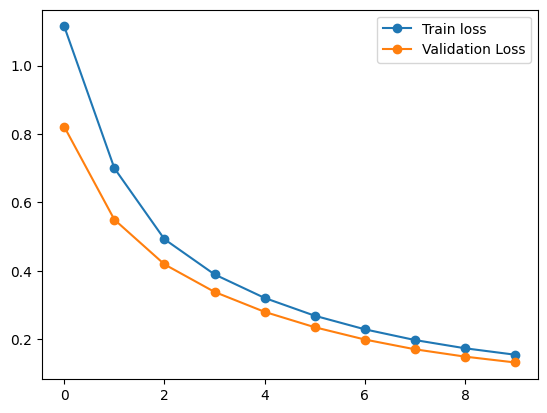

In [19]:
# Visualize the loss
fig, ax = plt.subplots()
ax.plot(history.history['loss'], label='Train loss', marker='o')
ax.plot(history.history['val_loss'], label='Validation Loss', marker='o')
ax.legend();

In [22]:
# 1. Build
model = Sequential()
model.add(Dense(30, input_dim=30, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# 2. Compile
model.compile(loss='bce', optimizer='adam')

# 3. Fit
history = model.fit(X_train_tf, y_train_enc,
                    validation_data=(X_test_tf, y_test_enc),
                    epochs=30)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.6717 - val_loss: 0.5300
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4662 - val_loss: 0.3755
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3568 - val_loss: 0.2827
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.2802 - val_loss: 0.2194
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2284 - val_loss: 0.1762
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1929 - val_loss: 0.1449
Epoch 7/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1672 - val_loss: 0.1235
Epoch 8/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1479 - val_loss: 0.1111
Epoch 9/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1325 - val_loss: 0.1001
Epoch 10/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1202 - val_loss: 0.0918
Epoch 11/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1106 - val_loss: 0.0853
Epoch 12/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1